Dataset Shape: (1200, 16)

Columns:
['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice', 'Year', 'Month']

First 5 rows:
     OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35   
2  ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003 2023-10-15     C33540    Chair         1     273.19   
4  ORD200004 2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    De

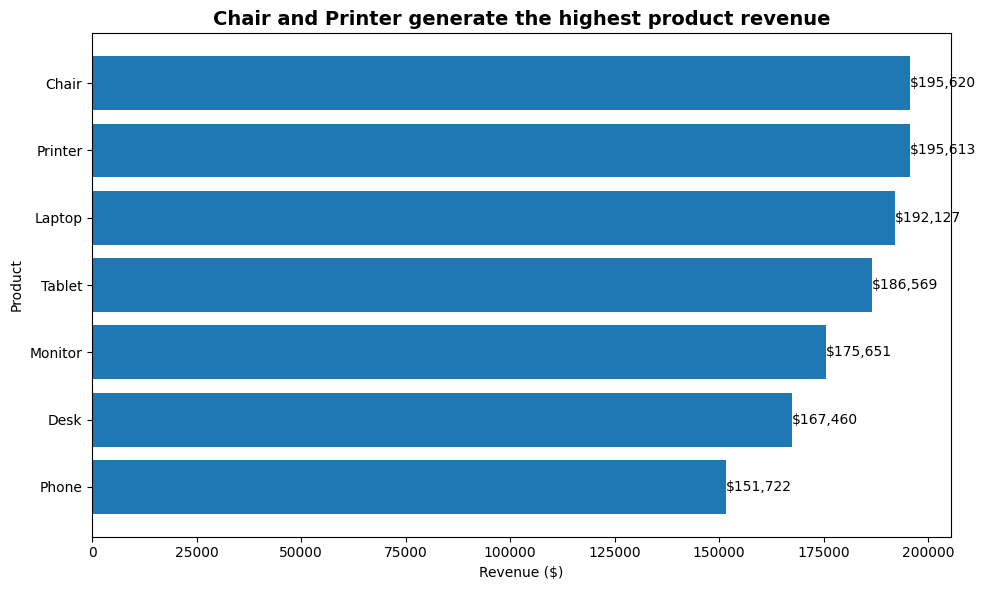

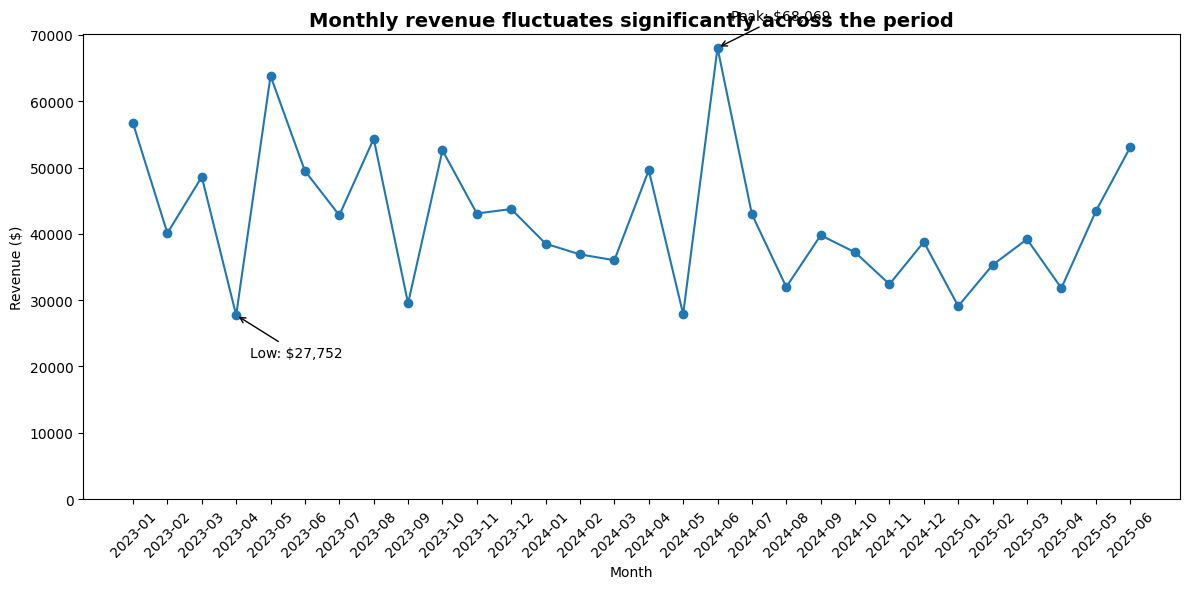

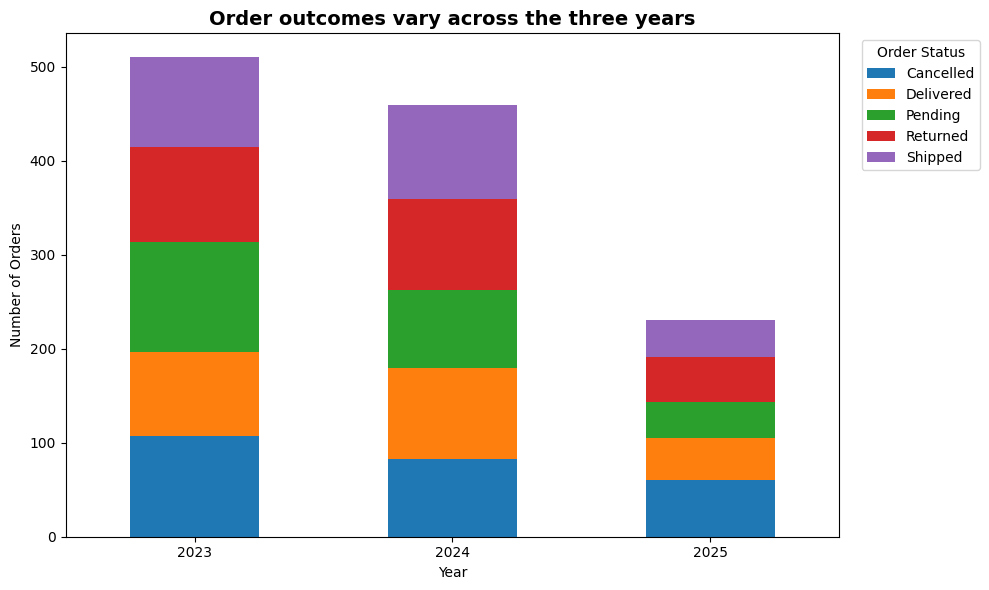

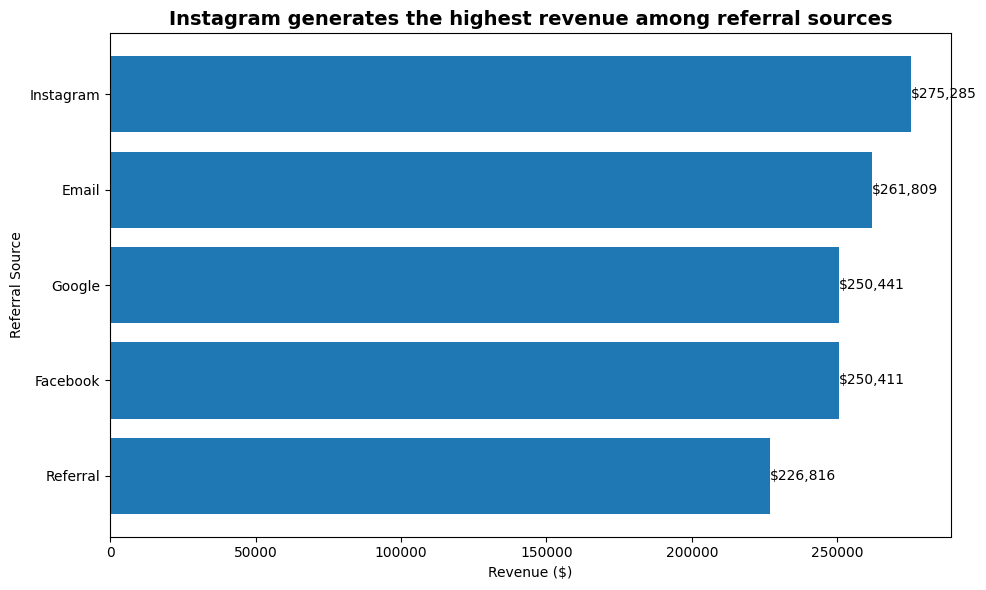

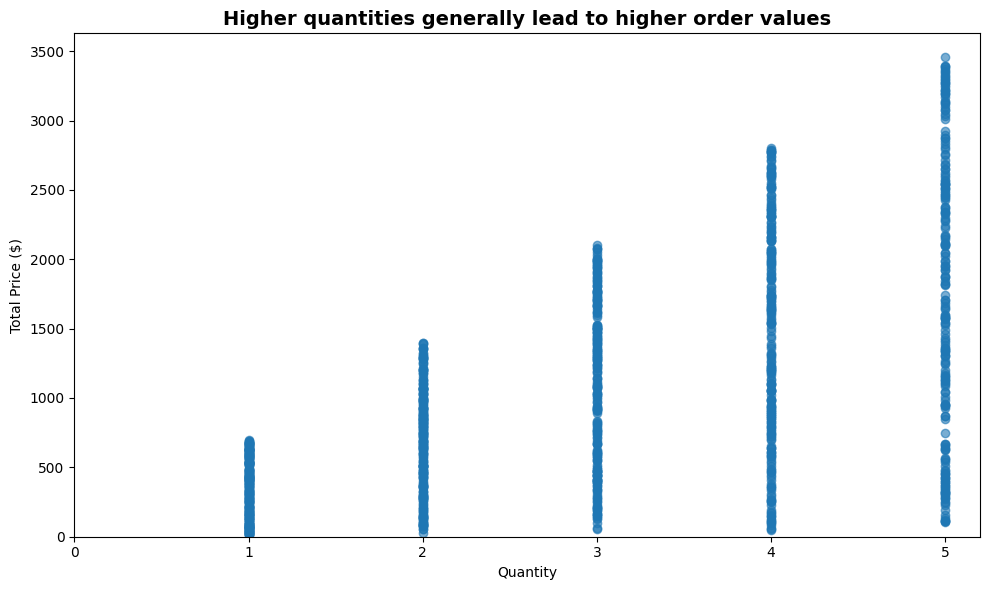


Total Revenue: $1,264,761.96
Total Orders: 1,200
Average Order: $1,053.97

Key Insights:
Chair generated the highest product revenue of $195,620.11.
Instagram generated the highest referral revenue of $275,285.45.
2023 recorded the highest annual revenue of $552,643.24.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "Dataset for Data Analytics.xlsx"

df = pd.read_excel(file_path)

df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.to_period("M").astype(str)

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nTotal Revenue:", round(df["TotalPrice"].sum(), 2))
print("Total Orders:", len(df))
print("Average Order Value:", round(df["TotalPrice"].mean(), 2))

product_revenue = (
    df.groupby("Product")["TotalPrice"]
    .sum()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    product_revenue.index,
    product_revenue.values
)

for bar in bars:
    value = bar.get_width()
    plt.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f"${value:,.0f}",
        va="center",
        ha="left"
    )

plt.title(
    "Chair and Printer generate the highest product revenue",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Revenue ($)")
plt.ylabel("Product")
plt.xlim(left=0)

plt.tight_layout()
plt.show()

monthly_revenue = (
    df.groupby("Month")["TotalPrice"]
    .sum()
)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker="o"
)

max_month = monthly_revenue.idxmax()
max_value = monthly_revenue.max()

min_month = monthly_revenue.idxmin()
min_value = monthly_revenue.min()

plt.annotate(
    f"Peak: ${max_value:,.0f}",
    xy=(max_month, max_value),
    xytext=(10, 20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.annotate(
    f"Low: ${min_value:,.0f}",
    xy=(min_month, min_value),
    xytext=(10, -30),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.title(
    "Monthly revenue fluctuates significantly across the period",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.ylim(bottom=0)

plt.tight_layout()
plt.show()

status_by_year = pd.crosstab(
    df["Year"],
    df["OrderStatus"]
)

status_by_year.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title(
    "Order outcomes vary across the three years",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)

plt.legend(
    title="Order Status",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

referral_revenue = (
    df.groupby("ReferralSource")["TotalPrice"]
    .sum()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    referral_revenue.index,
    referral_revenue.values
)

for bar in bars:
    value = bar.get_width()

    plt.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f"${value:,.0f}",
        va="center",
        ha="left"
    )

plt.title(
    "Instagram generates the highest revenue among referral sources",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Revenue ($)")
plt.ylabel("Referral Source")
plt.xlim(left=0)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Quantity"],
    df["TotalPrice"],
    alpha=0.6
)

plt.title(
    "Higher quantities generally lead to higher order values",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Quantity")
plt.ylabel("Total Price ($)")
plt.xlim(left=0)
plt.ylim(bottom=0)

plt.tight_layout()
plt.show()

total_revenue = df["TotalPrice"].sum()
total_orders = len(df)
average_order = df["TotalPrice"].mean()

print("\nTotal Revenue:", f"${total_revenue:,.2f}")
print("Total Orders:", f"{total_orders:,}")
print("Average Order:", f"${average_order:,.2f}")

top_product = product_revenue.idxmax()
top_product_revenue = product_revenue.max()

top_referral = referral_revenue.idxmax()
top_referral_revenue = referral_revenue.max()

best_year = (
    df.groupby("Year")["TotalPrice"]
    .sum()
    .idxmax()
)

best_year_revenue = (
    df.groupby("Year")["TotalPrice"]
    .sum()
    .max()
)

print("\nKey Insights:")

print(
    f"{top_product} generated the highest product revenue "
    f"of ${top_product_revenue:,.2f}."
)

print(
    f"{top_referral} generated the highest referral revenue "
    f"of ${top_referral_revenue:,.2f}."
)

print(
    f"{best_year} recorded the highest annual revenue "
    f"of ${best_year_revenue:,.2f}."
)